In [35]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.special import expit
from scipy.stats import binom
from empiricaldist import Pmf
from utils import (
    decorate, 
    make_uniform, 
    make_joint, 
    plot_contour, 
    marginal
)

sns.set_style('darkgrid')
warnings.filterwarnings("ignore")

## 16.2 The Space Shuttle Problem

In [3]:
data = pd.read_csv('./data/challenger_data.csv', parse_dates=[0])

# avoiding column names with spaces
data.rename(columns={'Damage Incident': 'Damage'}, inplace=True)

# dropping row 3, in which Damage Incident is NaN,
# and row 24, which is the record for the Challenger
data.drop(labels=[3, 24], inplace=True)

# convert the Damage column to integer
data['Damage'] = data['Damage'].astype(int)

data

,Date,Temperature,Damage
0,04/12/1981,66,0
1,11/12/1981,70,1
2,3/22/82,69,0
4,01/11/1982,68,0
5,04/04/1983,67,0
6,6/18/83,72,0
7,8/30/83,73,0
8,11/28/83,70,0
9,02/03/1984,57,1
10,04/06/1984,63,1


In [4]:
len(data), data['Damage'].sum()

(23, 7)

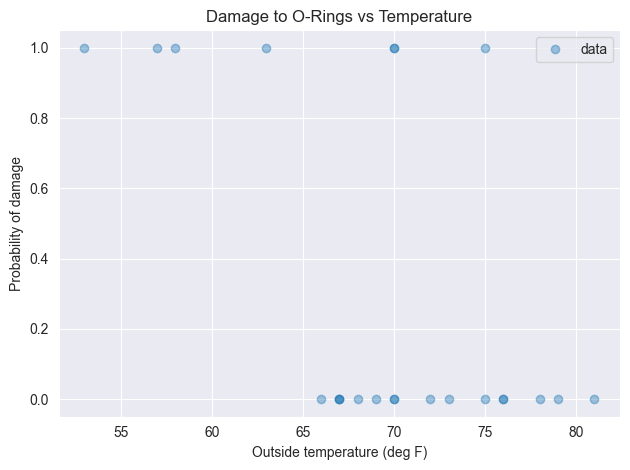

In [8]:
def plot_data(data):
    """Plot damage as a function of temperature.
    
    data: DataFrame
    """
    plt.plot(
        data['Temperature'], data['Damage'], 'o', 
        label='data', color='C0', alpha=0.4
    )

    decorate(
        ylabel="Probability of damage",
        xlabel="Outside temperature (deg F)",
        title="Damage to O-Rings vs Temperature"
    )

plot_data(data)

In [9]:
offset = data['Temperature'].mean().round()
data['x'] = data['Temperature'] - offset
data['y'] = data['Damage']

In [11]:
formula = 'y ~ x'
results = smf.logit(formula, data=data).fit(disp=False)
results.params

Intercept   -1.208490
x           -0.232163
dtype: float64

In [15]:
inter = results.params['Intercept']
slope = results.params['x']
xs = np.arange(53, 83) - offset
log_odds = inter + slope * xs
ps = expit(log_odds)

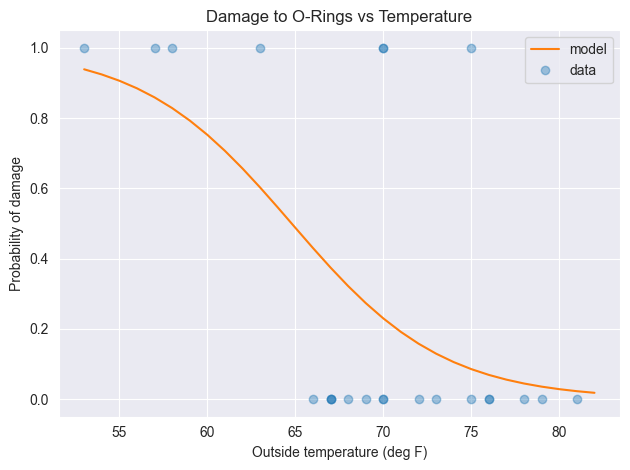

In [16]:
plt.plot(xs + offset, ps, label='model', color='C1')
plot_data(data)

## 16.3 Prior Distribution

In [23]:
qs = np.linspace(-5, 1, num=101)
prior_inter = make_uniform(qs, 'Intercept')

qs = np.linspace(-0.8, 0.1, num=101)
prior_slope = make_uniform(qs, 'Slope')

joint = make_joint(prior_inter, prior_slope)

joint_pmf = Pmf(joint.stack())
joint_pmf.head()

Slope  Intercept
-0.8   -5.00        0.000098
       -4.94        0.000098
       -4.88        0.000098
dtype: float64

## 16.4 Likelihood

In [25]:
grouped = data.groupby('x')['y'].agg(['count', 'sum'])
grouped.head()

,count,sum
x,,
-17.0,1,1
-13.0,1,1
-12.0,1,1
-7.0,1,1
-4.0,1,0


In [26]:
ns = grouped['count']
ks = grouped['sum']
xs = grouped.index
ps = expit(inter + slope * xs)

In [27]:
likelihood = joint_pmf.copy()
for slope, inter in joint_pmf.index:
    ps = expit(inter + slope * xs)
    likes = binom.pmf(ks, ns, ps)
    likelihood[slope, inter] = likes.prod() 

## 16.5 The Update

In [28]:
posterior_pmf = joint_pmf * likelihood
posterior_pmf.normalize()

3.508992289655609e-05

In [29]:
pd.Series(
    posterior_pmf.max_prob(),
    index=['slope', 'inter']
)

slope   -0.233
inter   -1.220
dtype: float64

In [30]:
results.params

Intercept   -1.208490
x           -0.232163
dtype: float64

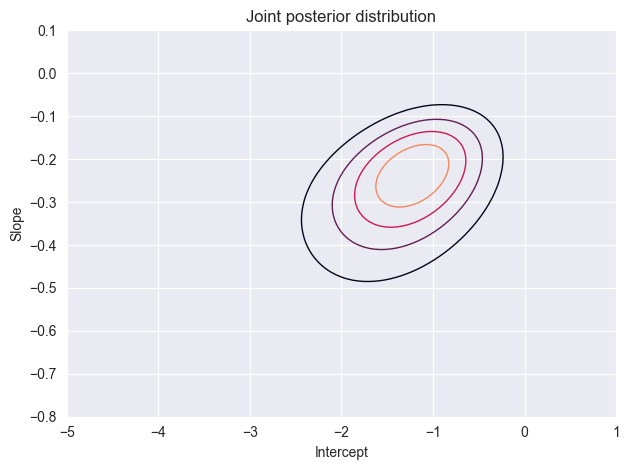

In [34]:
joint_posterior = posterior_pmf.unstack()
plot_contour(joint_posterior)
decorate(title='Joint posterior distribution')

## 16.6 Marginal Distributions

In [36]:
marginal_inter = marginal(joint_posterior, 0)
marginal_slope = marginal(joint_posterior, 1)

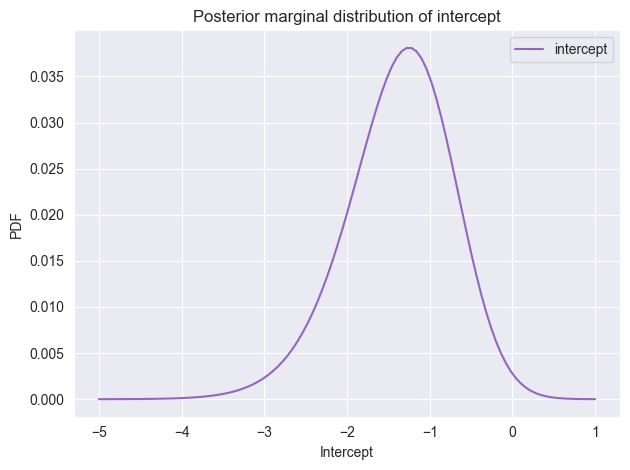

In [37]:
marginal_inter.plot(label='intercept', color='C4')

decorate(
    xlabel='Intercept',
    ylabel='PDF',
    title='Posterior marginal distribution of intercept'
)

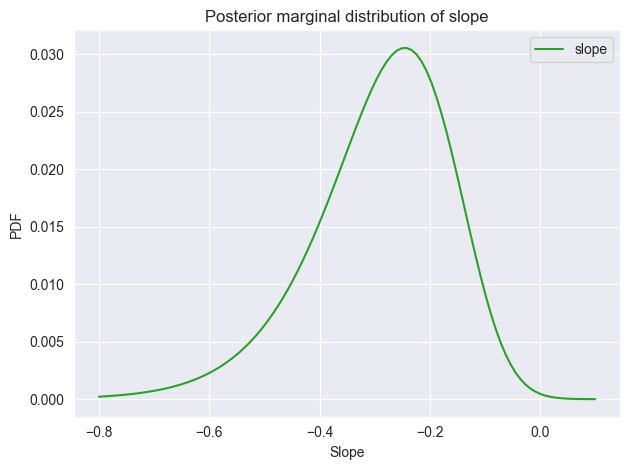

In [38]:
marginal_slope.plot(label='slope', color='C2')
decorate(
    xlabel='Slope',
    ylabel='PDF',
    title='Posterior marginal distribution of slope'
)

In [39]:
pd.Series(
    [marginal_inter.mean(), marginal_slope.mean()],
    index=['inter', 'slope']
)

inter   -1.376107
slope   -0.289795
dtype: float64

In [40]:
results.params

Intercept   -1.208490
x           -0.232163
dtype: float64

## 16.7 Transforming Distributions

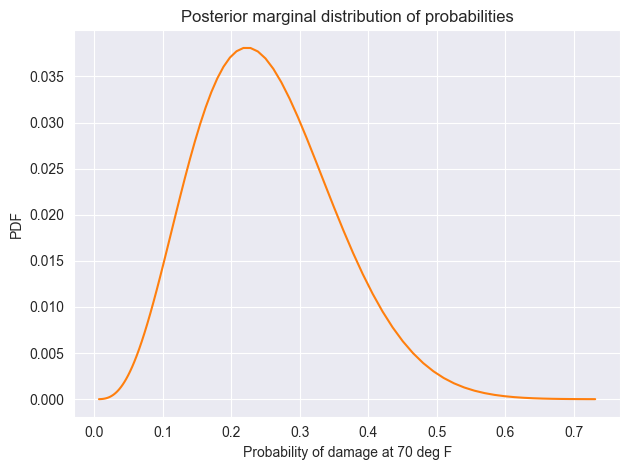

In [41]:
marginal_probs = marginal_inter.transform(expit)

marginal_probs.plot(color='C1')
decorate(
    xlabel='Probability of damage at 70 deg F',
    ylabel='PDF',
    title='Posterior marginal distribution of probabilities'
)

In [42]:
mean_prob = marginal_probs.mean()
mean_prob

0.2201937884647988

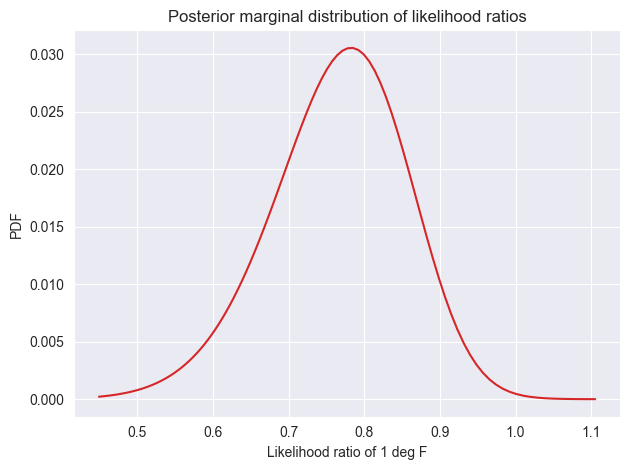

In [43]:
marginal_lr = marginal_slope.transform(np.exp)
marginal_lr.plot(color='C3')

decorate(
    xlabel='Likelihood ratio of 1 deg F',
    ylabel='PDF',
    title='Posterior marginal distribution of likelihood ratios'
)

In [44]:
mean_lr = marginal_lr.mean()
mean_lr

0.7542914170110269

## 16.8 Predictive Distributions

In [45]:
sample = posterior_pmf.choice(101)

temps = np.arange(31, 83)
xs = temps - offset

pred = np.empty((len(sample), len(xs)))
for i, (slope, inter) in enumerate(sample):
    pred[i] = expit(inter + slope * xs)

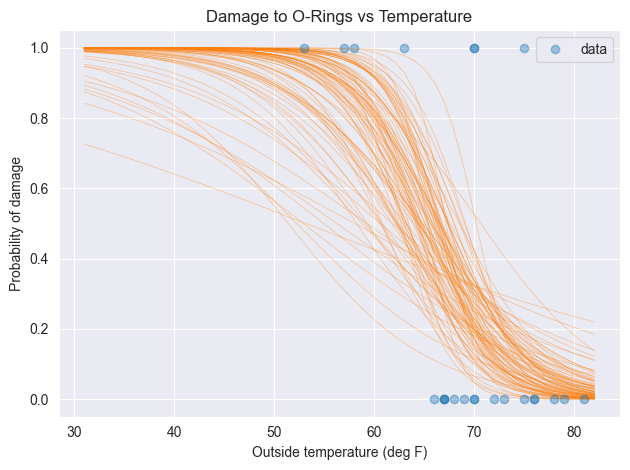

In [46]:
for ps in pred:
    plt.plot(temps, ps, color='C1', lw=0.5, alpha=0.4)
    
plot_data(data)

In [47]:
low, median, high = np.percentile(pred, [5, 50, 95], axis=0)

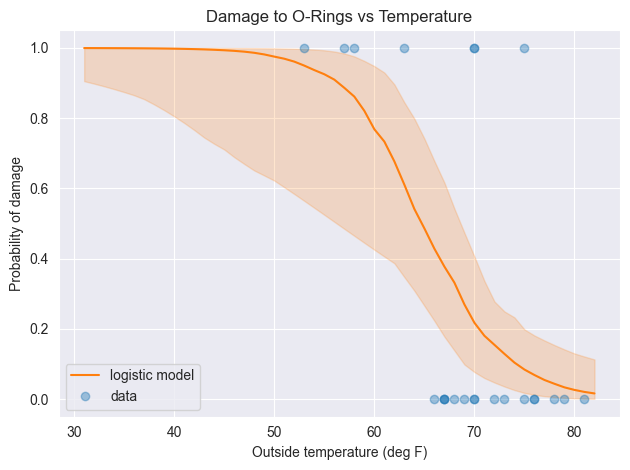

In [48]:
plt.fill_between(temps, low, high, color='C1', alpha=0.2)
plt.plot(temps, median, color='C1', label='logistic model')

plot_data(data)

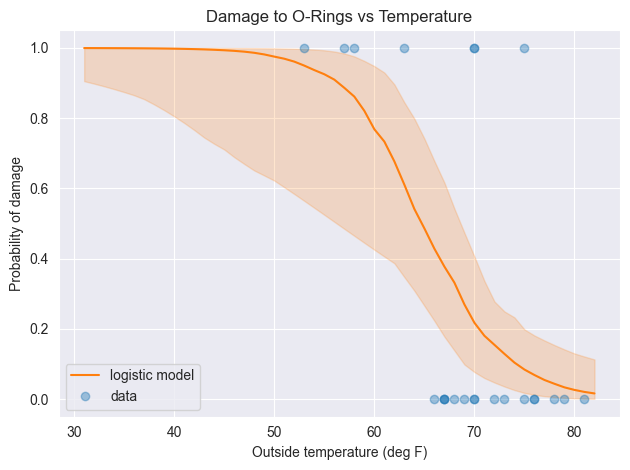

In [49]:
plt.fill_between(temps, low, high, color='C1', alpha=0.2)
plt.plot(temps, median, color='C1', label='logistic model')

plot_data(data)

In [50]:
low = pd.Series(low, temps)
median = pd.Series(median, temps)
high = pd.Series(high, temps)

In [51]:
t = 80
print(median[t], (low[t], high[t]))

0.026339319625283387 (0.0025224474607696942, 0.13010847436299788)


In [52]:
t = 60
print(median[t], (low[t], high[t]))

0.7685247834990178 (0.42555748318834086, 0.9483385645339152)


In [53]:
t = 31
print(median[t], (low[t], high[t]))

0.9997586449287836 (0.9055096310498406, 0.9999992208020997)
